Daily Chalange Week 4 Day 5

In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
ds_salaries = pd.read_csv('ds_salaries.csv')

Saving ds_salaries.csv to ds_salaries.csv


Analysing the dataset

In [22]:
ds_salaries.head()
ds_salaries.info()
ds_salaries.isnull().sum()
ds_salaries.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


There is no missing data , the total number of rows is 607, the next step would be deleting duplicated rows


In [5]:
ds_salaries.drop_duplicates(inplace=True)
ds_salaries.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


there is no duplicated rows

Bofore starting the analysis , there is a need to see unique values

In [12]:
unique_values = ds_salaries.apply(pd.Series.unique)
for column, unique_vals in unique_values.items():
  print(f"Unique values in column '{column}':")
  print(unique_vals)

Unique values in column 'Unnamed: 0':
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 

as for the data type - quantitive would be float and integer, while qualitative data outlined as object

In [13]:
quantitative_columns = ds_salaries.select_dtypes(include=['float64', 'int64']).columns
print(f"Quantitative columns: {quantitative_columns}\n")

qualitative_columns = ds_salaries.select_dtypes(include=['object']).columns
print(f"Qualitative columns: {qualitative_columns}\n")

Quantitative columns: Index(['Unnamed: 0', 'work_year', 'salary', 'salary_in_usd', 'remote_ratio'], dtype='object')

Qualitative columns: Index(['experience_level', 'employment_type', 'job_title', 'salary_currency',
       'employee_residence', 'company_location', 'company_size'],
      dtype='object')



in order to proceed with the analysis there is a need to outline and adjust dataset accordingly if there are the outliners. the chosen method is the IQR Method, to see if there are the outliners in ['salary']

In [18]:
Q1 = ds_salaries['salary'].quantile(0.25)
Q3 = ds_salaries['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ds_salaries[(ds_salaries['salary'] < lower_bound) | (ds_salaries['salary'] > upper_bound)]
print("Number of outliers detected:", len(outliers))


Number of outliers detected: 44


In [21]:
ds_salaries_new = ds_salaries[(ds_salaries['salary'] >= lower_bound) & (ds_salaries['salary'] <= upper_bound)]
print(ds_salaries_new)
ds_salaries_new.describe()

     Unnamed: 0  work_year experience_level employment_type  \
0             0       2020               MI              FT   
1             1       2020               SE              FT   
2             2       2020               SE              FT   
3             3       2020               MI              FT   
4             4       2020               SE              FT   
..          ...        ...              ...             ...   
602         602       2022               SE              FT   
603         603       2022               SE              FT   
604         604       2022               SE              FT   
605         605       2022               SE              FT   
606         606       2022               MI              FT   

                      job_title  salary salary_currency  salary_in_usd  \
0                Data Scientist   70000             EUR          79833   
1    Machine Learning Scientist  260000             USD         260000   
2             Big Dat

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,563.000000,563.000000,563.000000,563.00000,563.000000
mean,311.698046,2021.442274,113104.868561,111726.16341,71.403197
std,174.506853,0.683920,59369.779786,56921.66283,40.779580
min,0.000000,2020.000000,4000.000000,2859.00000,0.000000
25%,161.500000,2021.000000,65000.000000,68714.00000,50.000000
50%,318.000000,2022.000000,108800.000000,105000.00000,100.000000
75%,461.500000,2022.000000,150630.000000,150000.00000,100.000000
max,606.000000,2022.000000,300000.000000,276000.00000,100.000000


we can see without outliners the fugures are looking smoother and STD is lesser by 20k

In [23]:
location_experience_stats = ds_salaries_new.groupby(['company_location', 'experience_level'])['salary'].agg(['mean', 'median']).reset_index()

print("Salary statistics by company location and experience level:")
print(location_experience_stats)



Salary statistics by company location and experience level:
   company_location experience_level           mean    median
0                AE               MI  115000.000000  115000.0
1                AE               SE   92500.000000   92500.0
2                AT               MI   58666.666667   59000.0
3                AT               SE   80000.000000   80000.0
4                AU               EN  135000.000000  135000.0
..              ...              ...            ...       ...
80               US               EN   93112.903226   90000.0
81               US               EX  186239.583333  187500.0
82               US               MI  119285.811765  112000.0
83               US               SE  148474.308411  145000.0
84               VN               EN    4000.000000    4000.0

[85 rows x 4 columns]


Group-wise Analysis by `company_location` and `experience_level

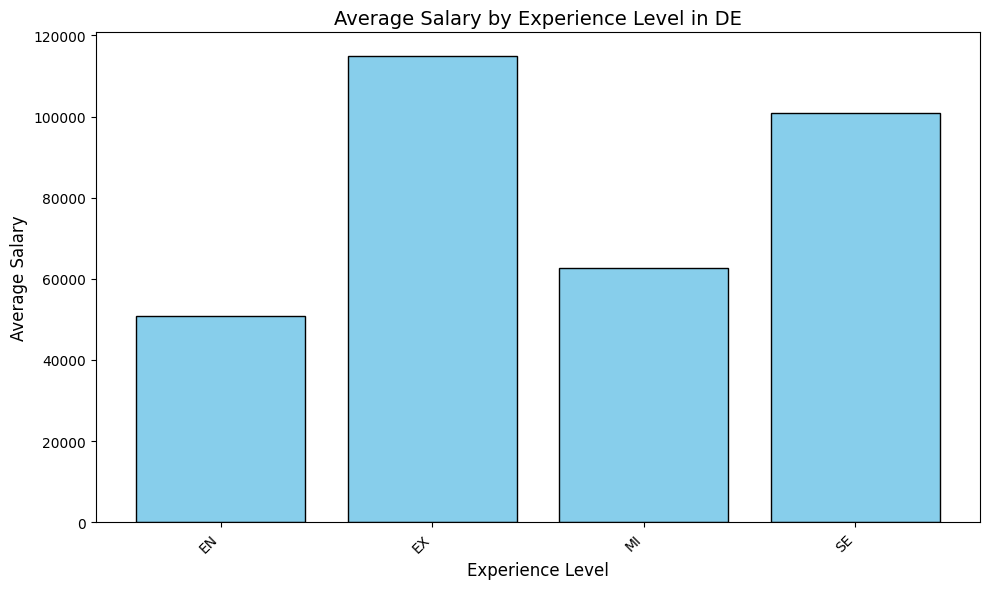

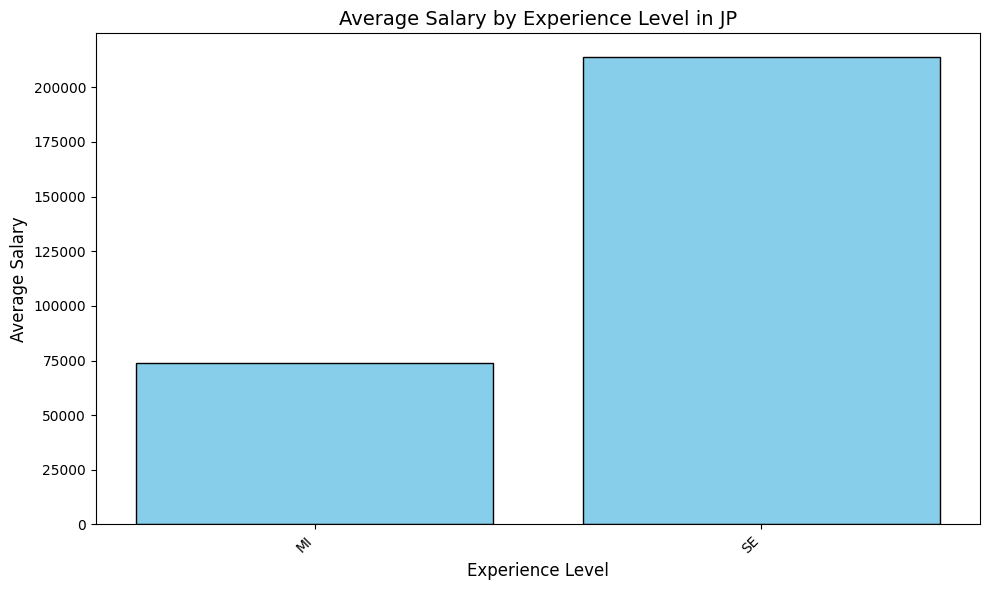

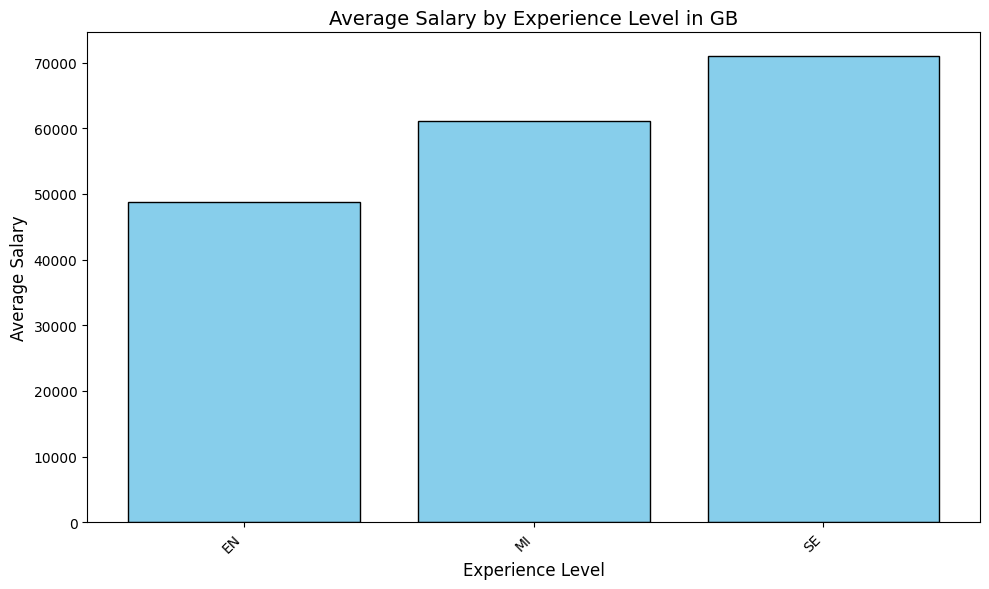

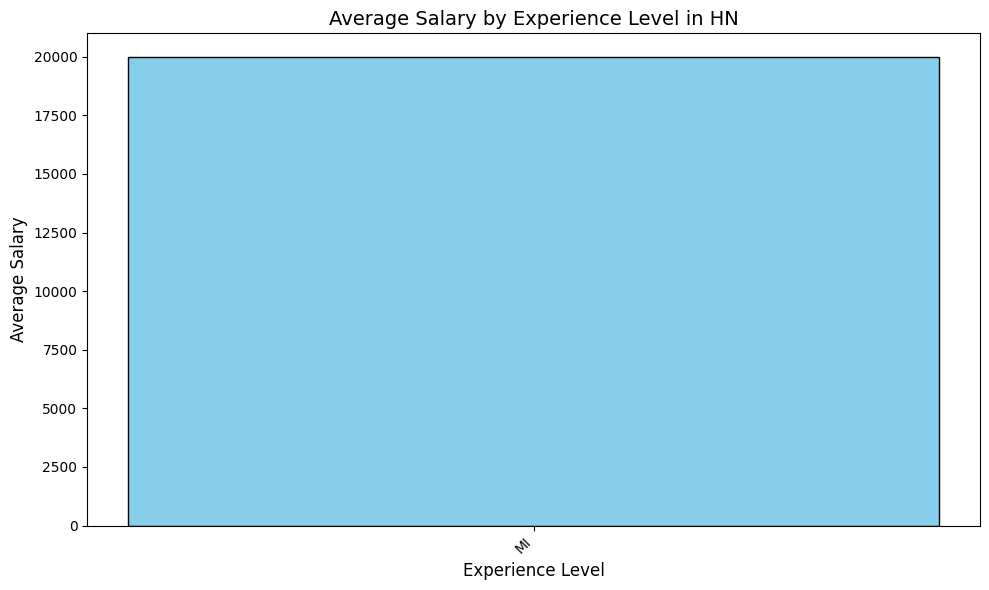

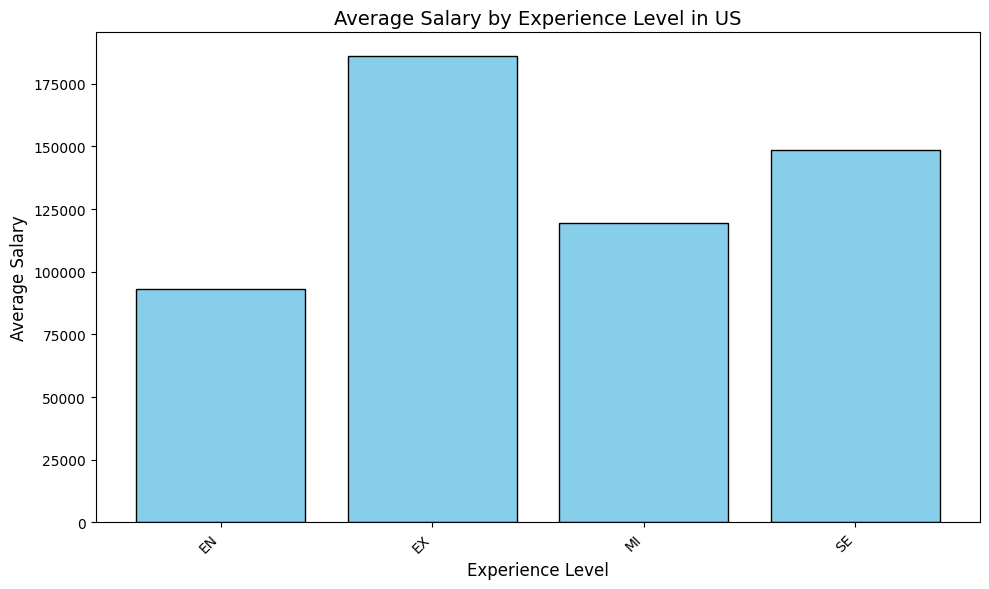

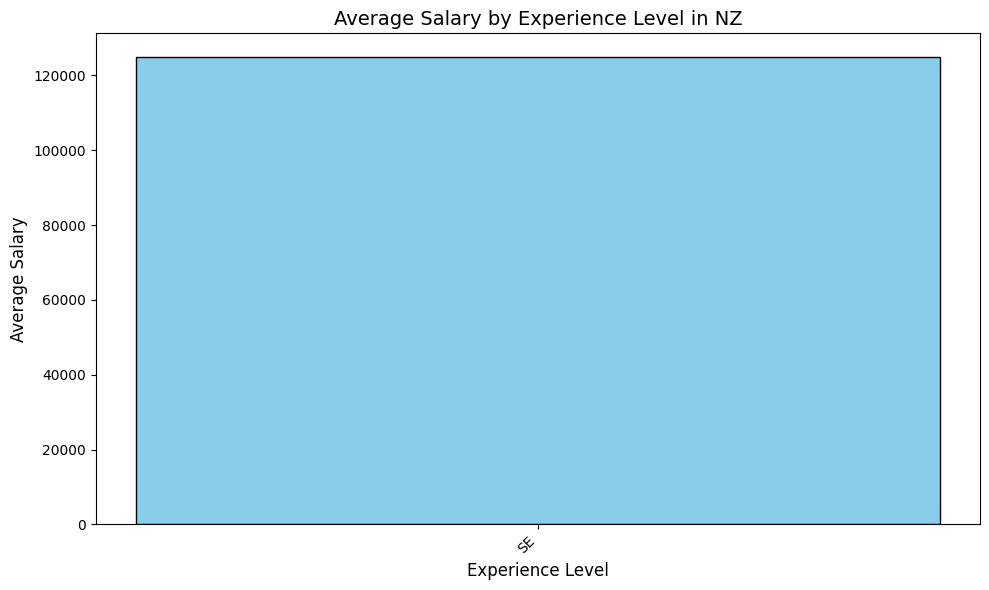

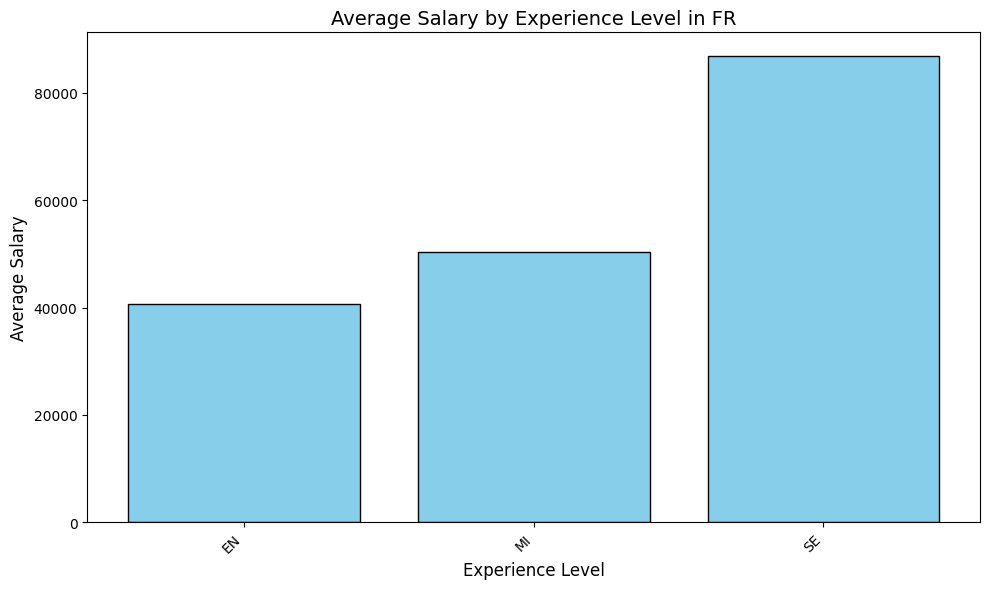

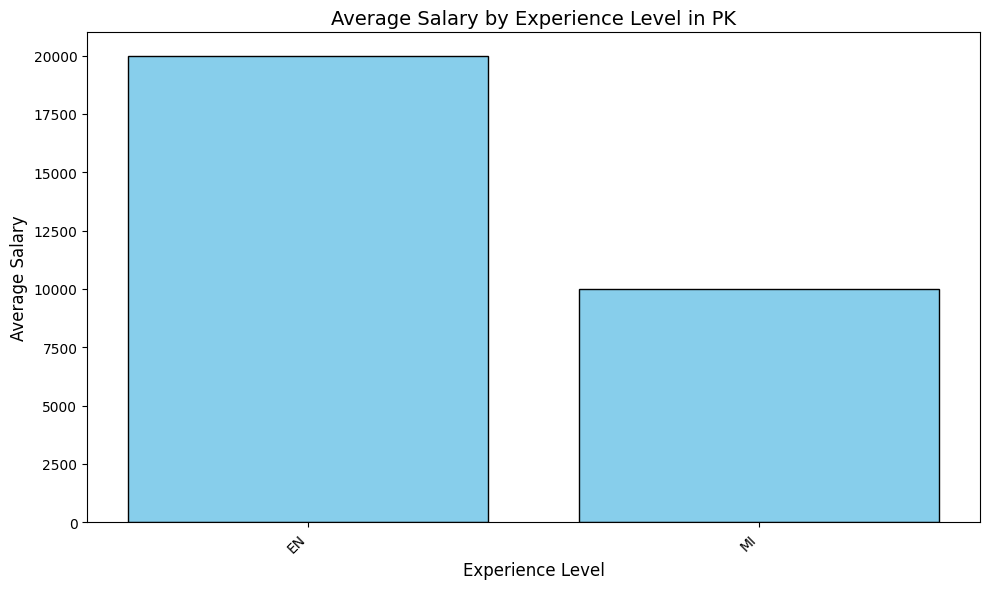

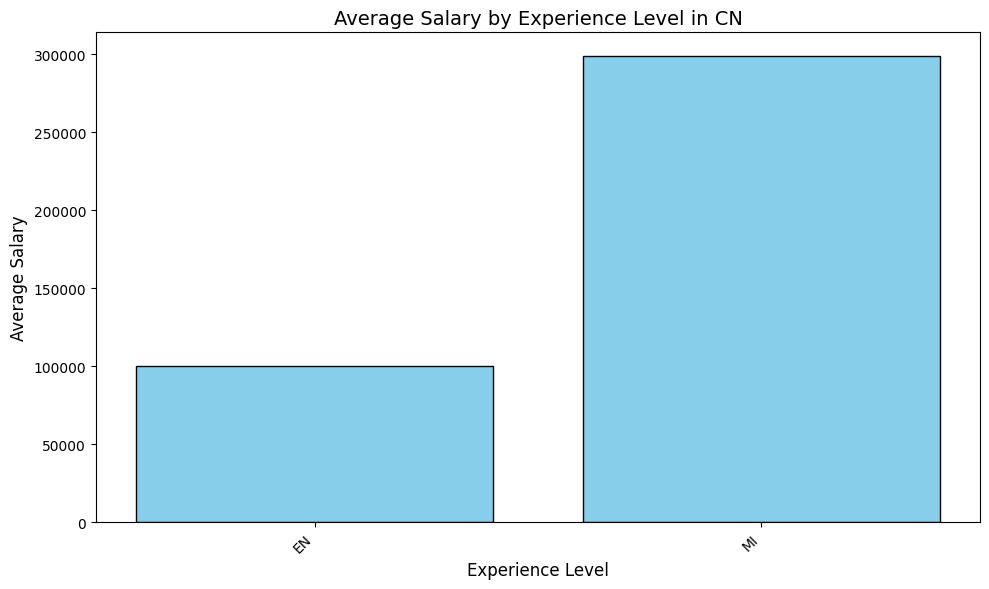

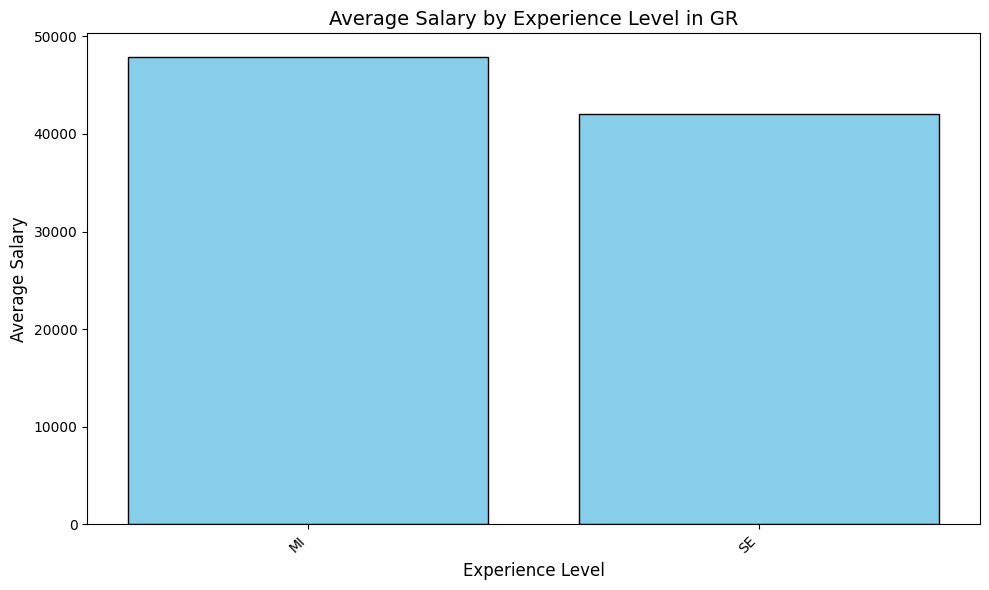

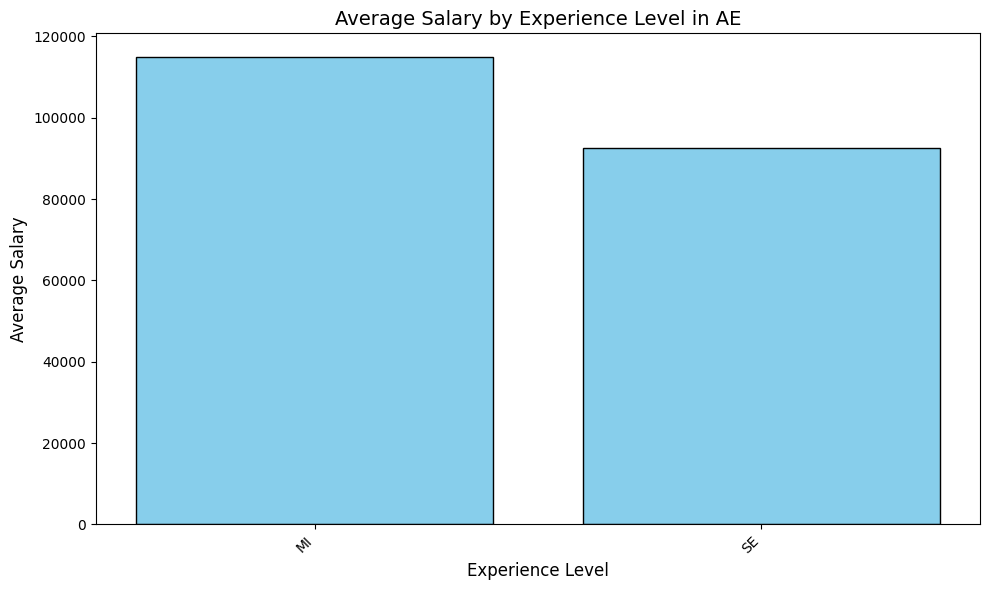

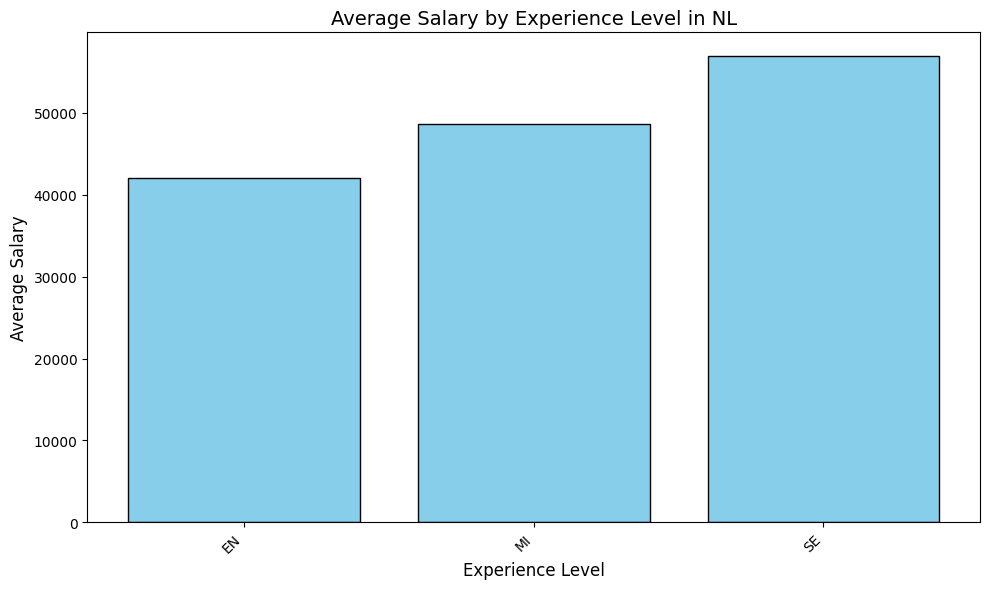

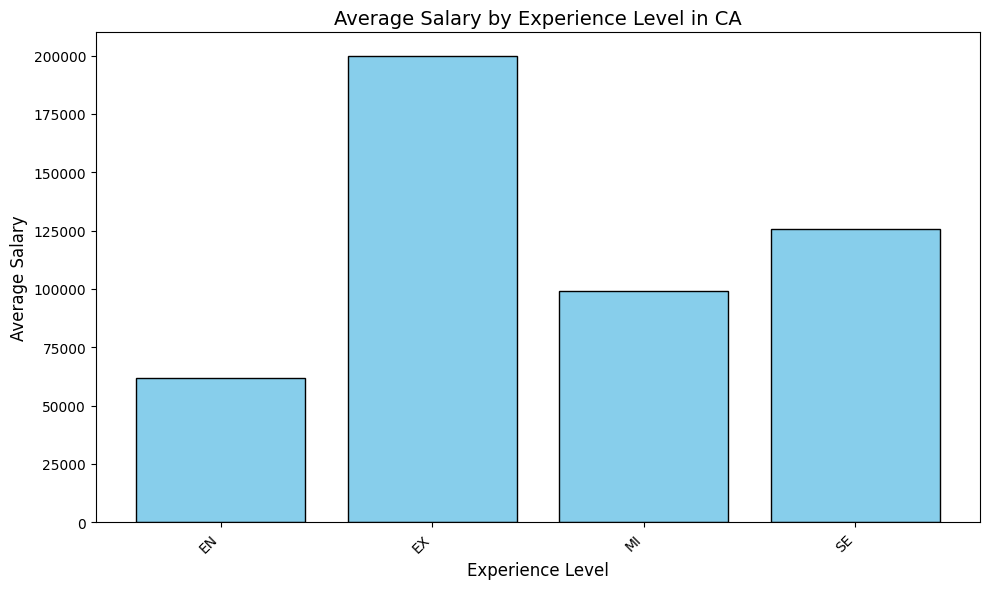

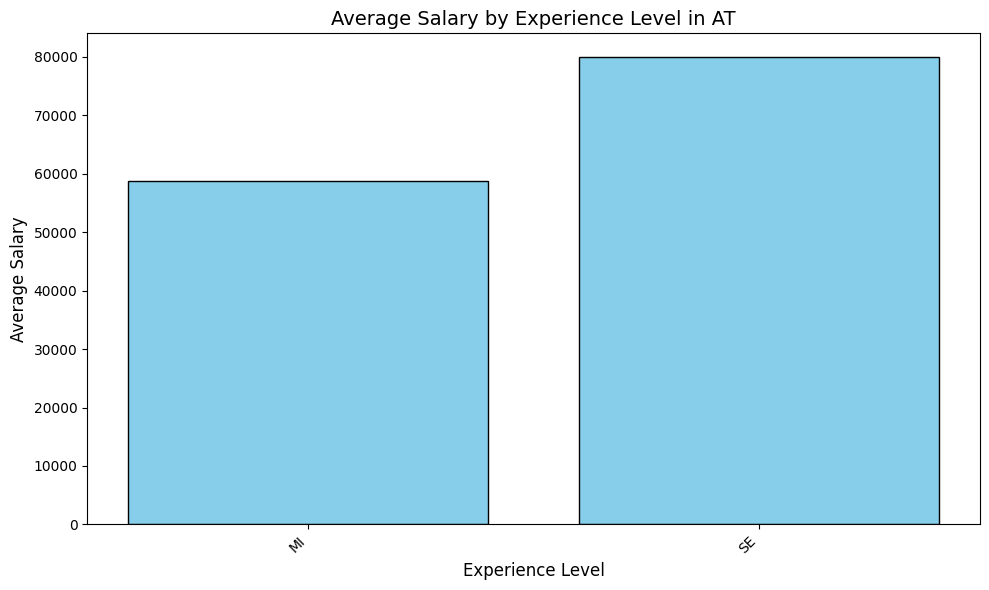

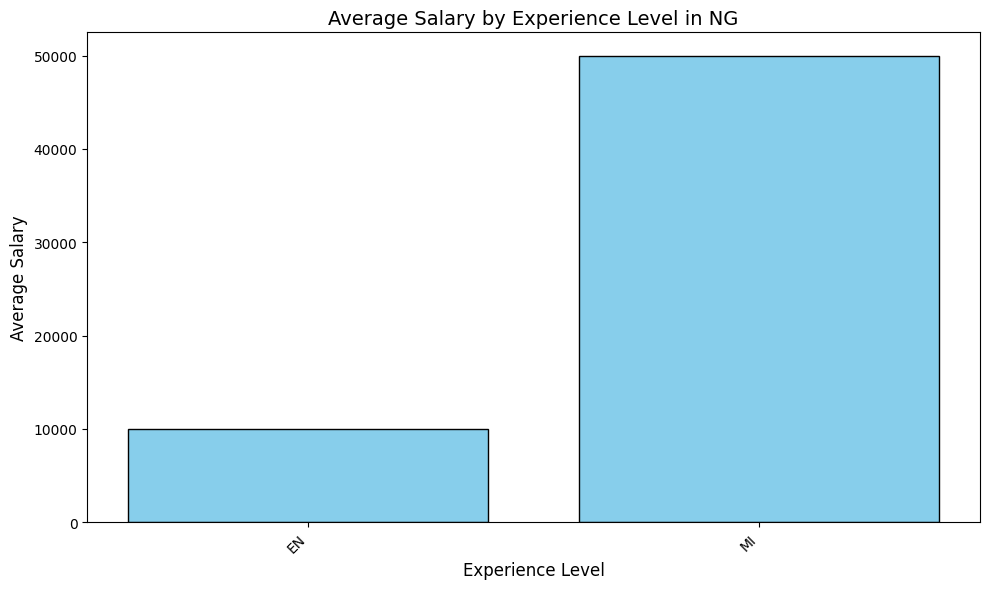

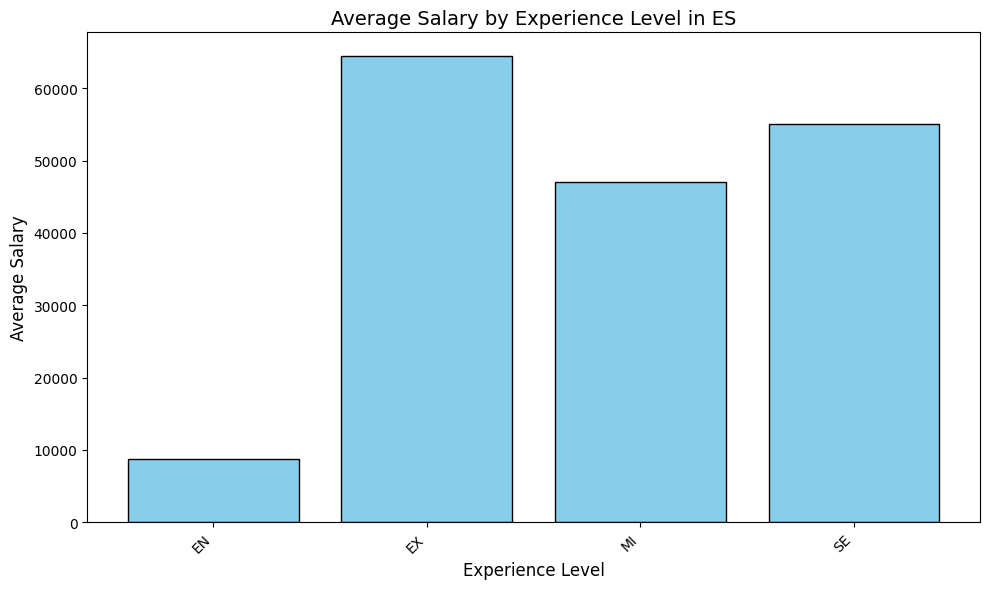

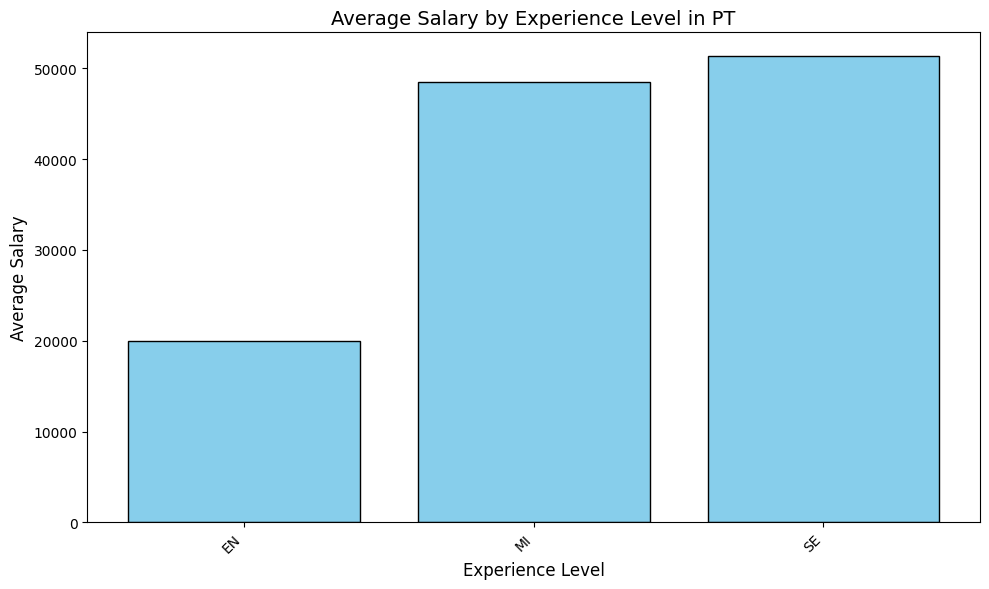

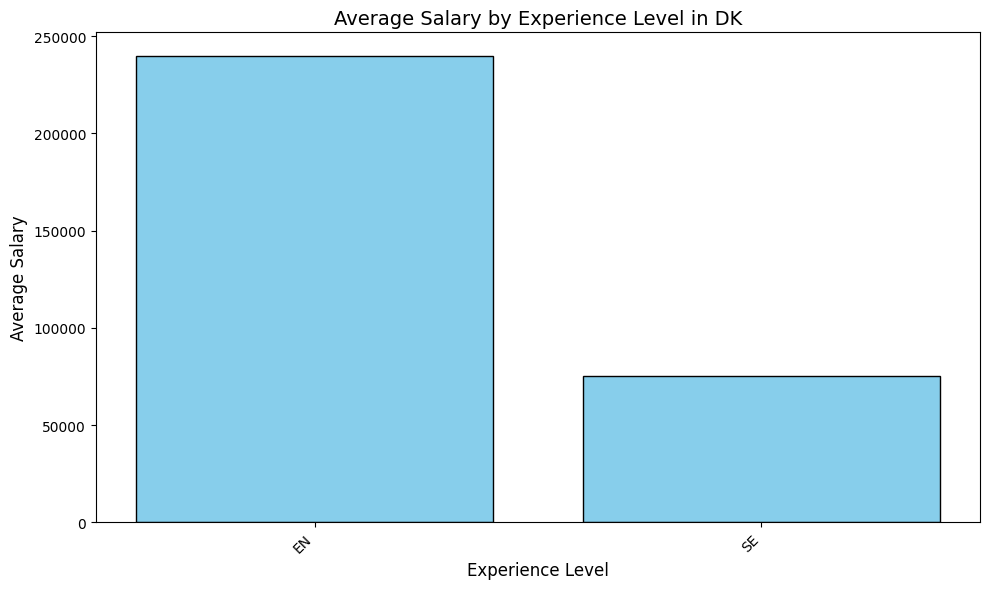

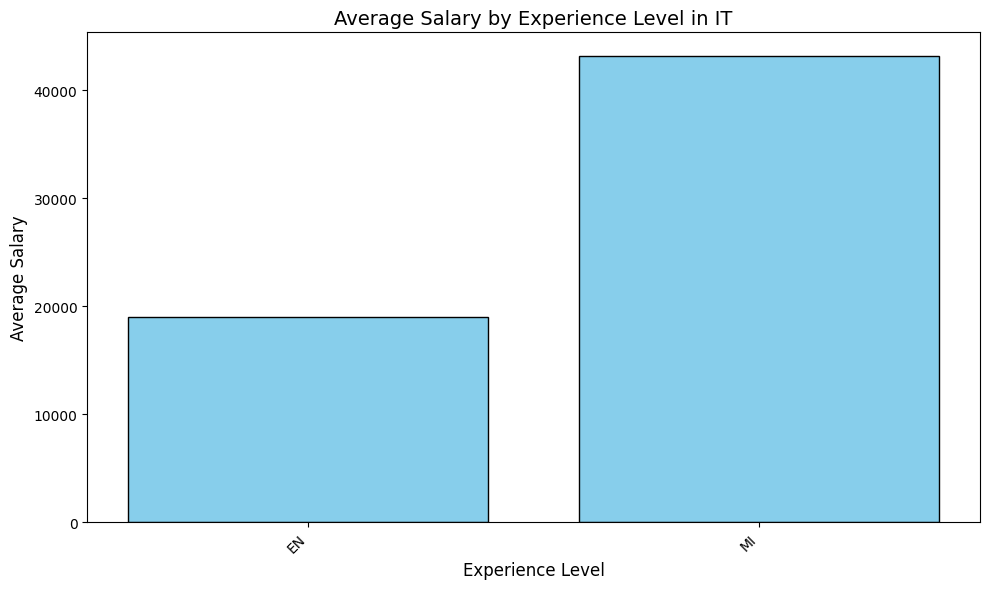

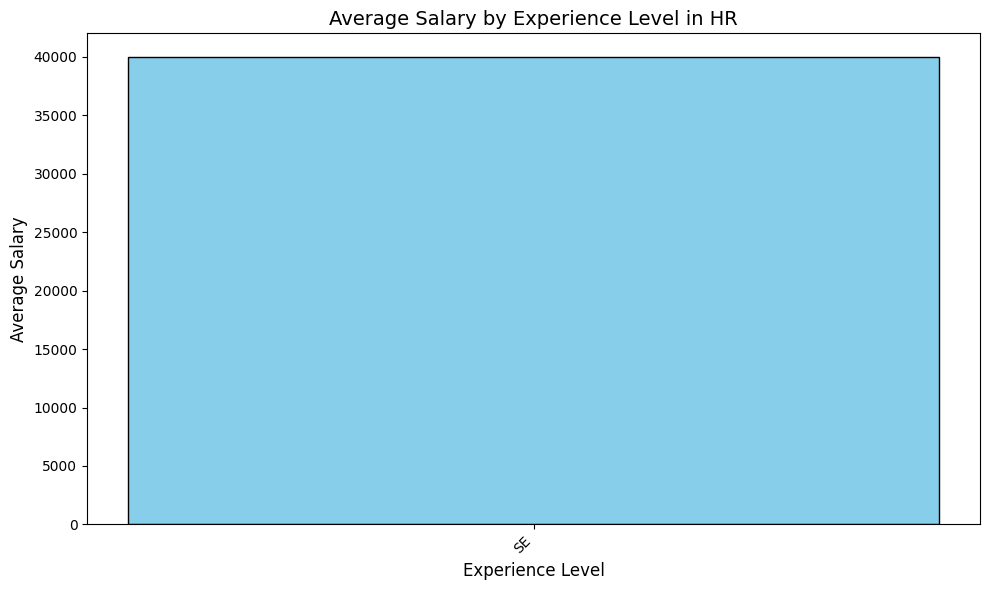

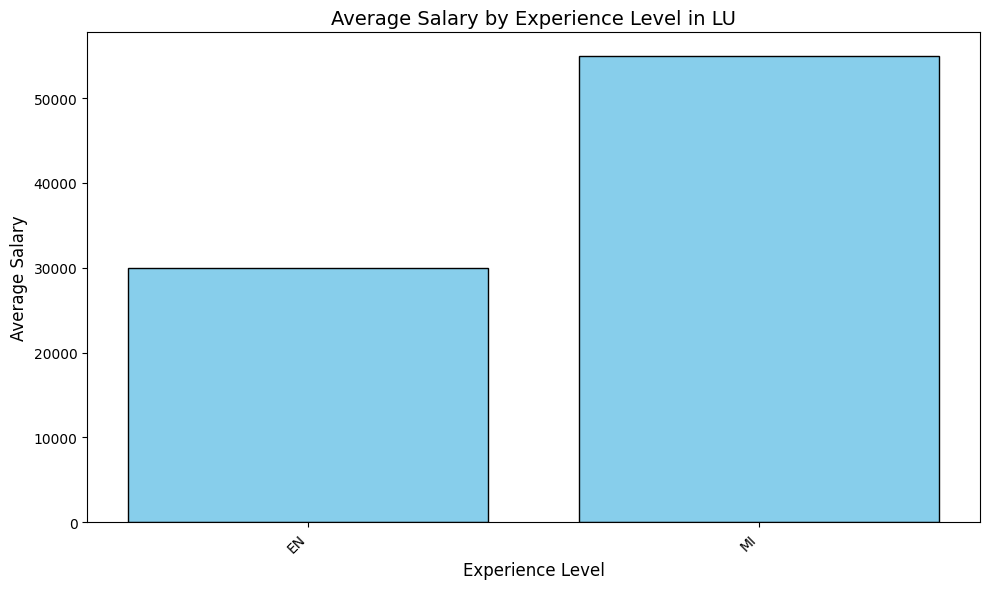

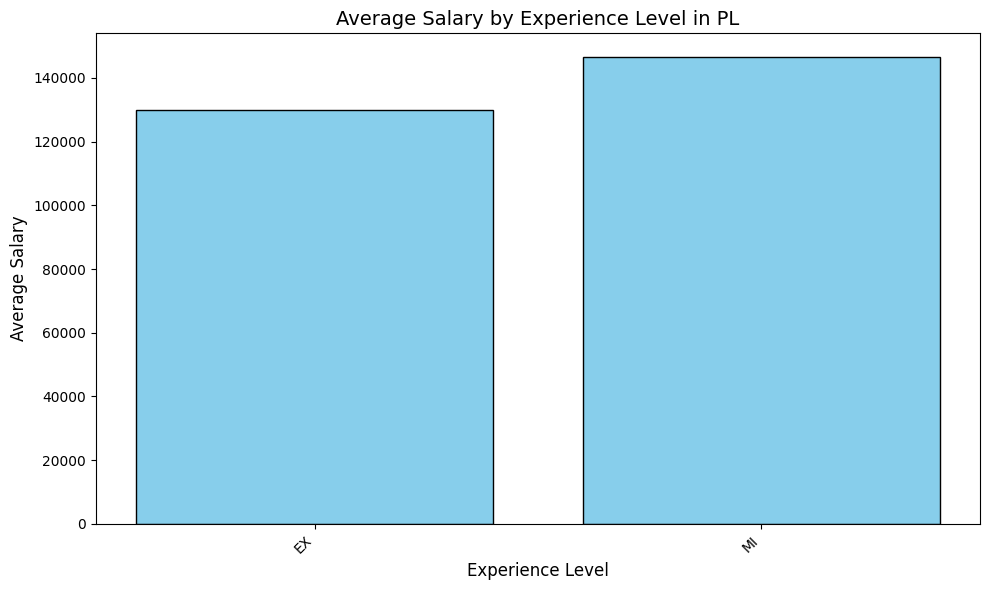

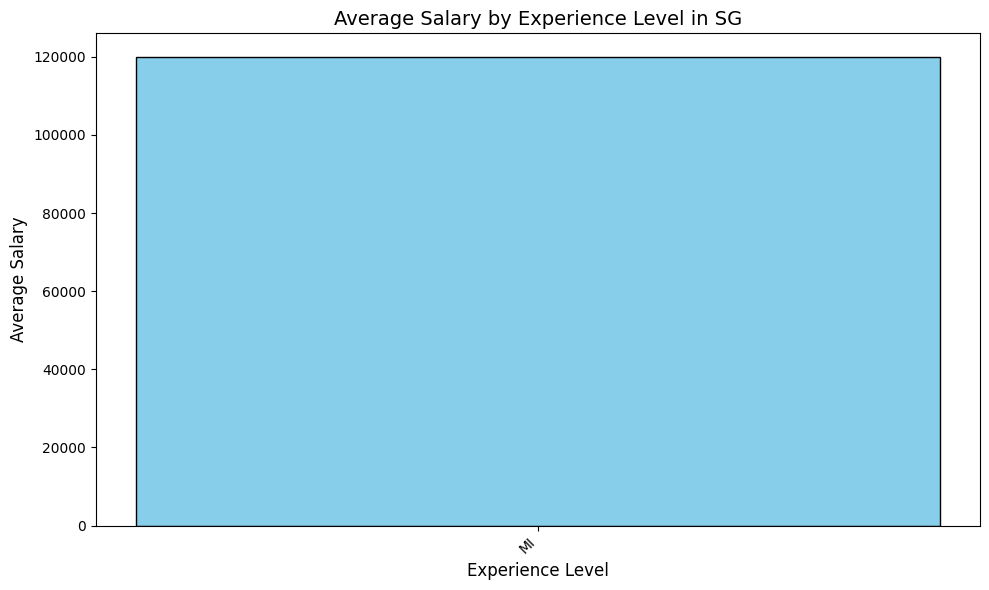

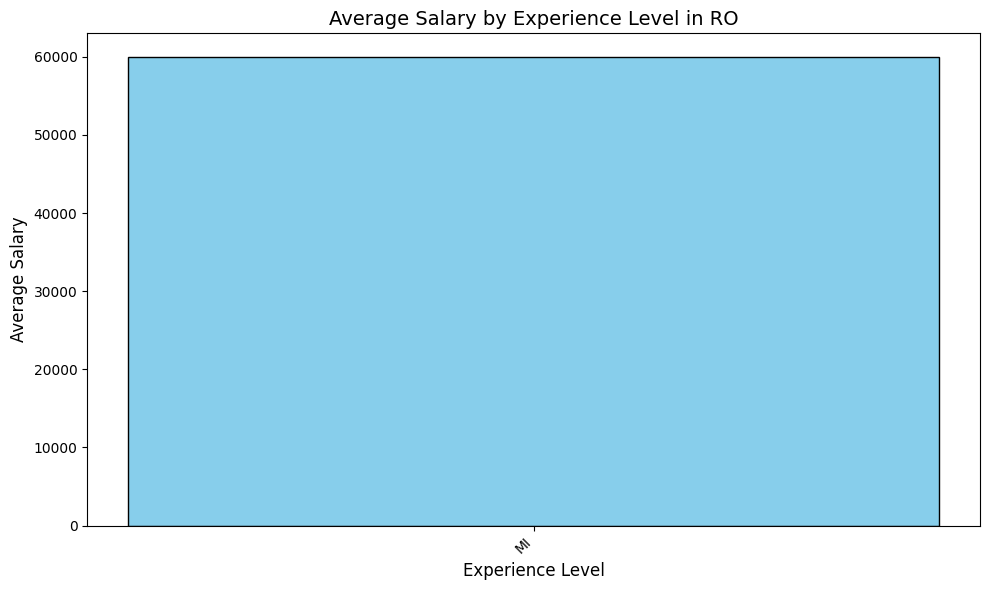

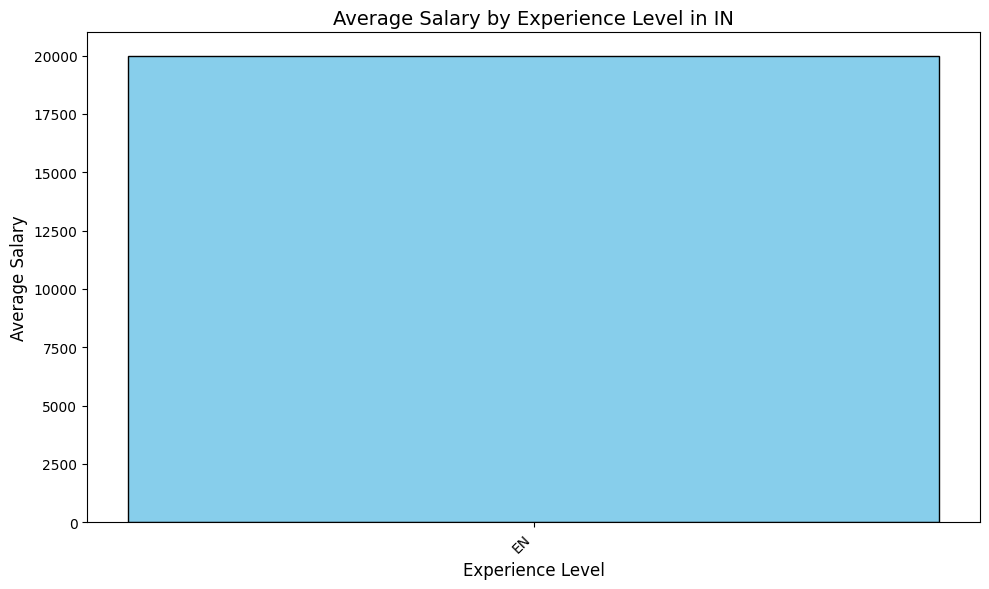

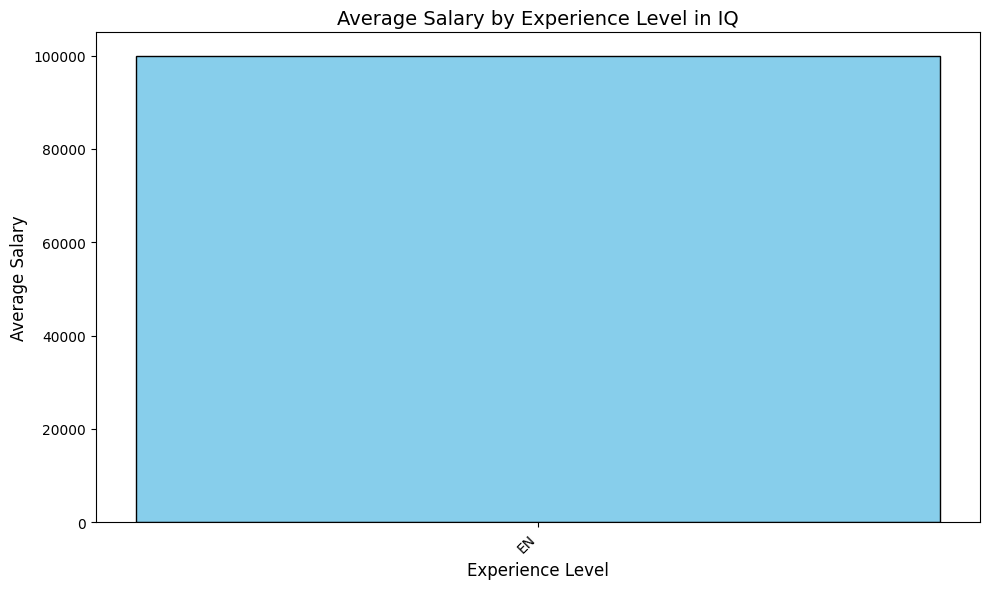

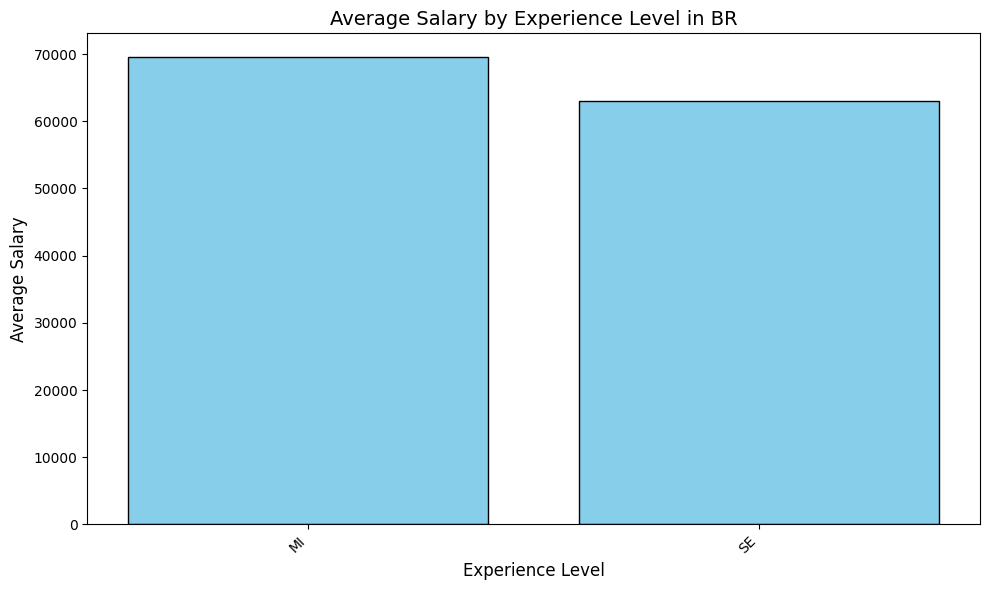

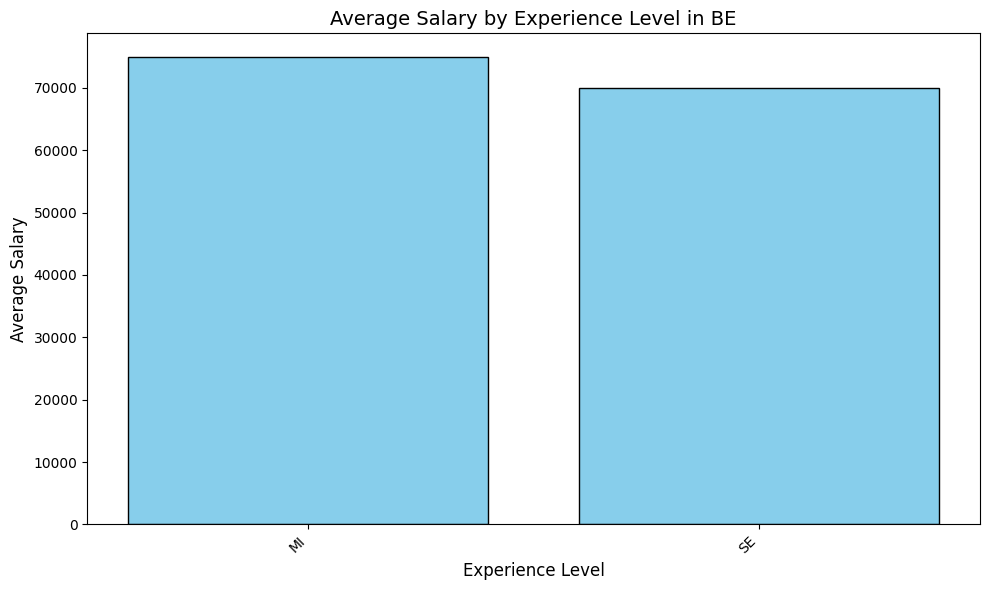

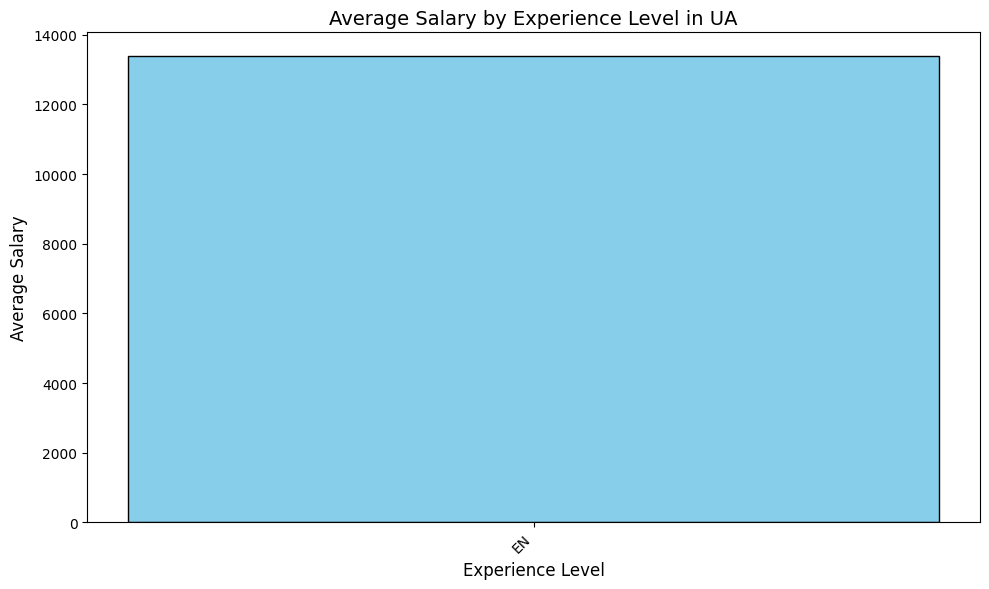

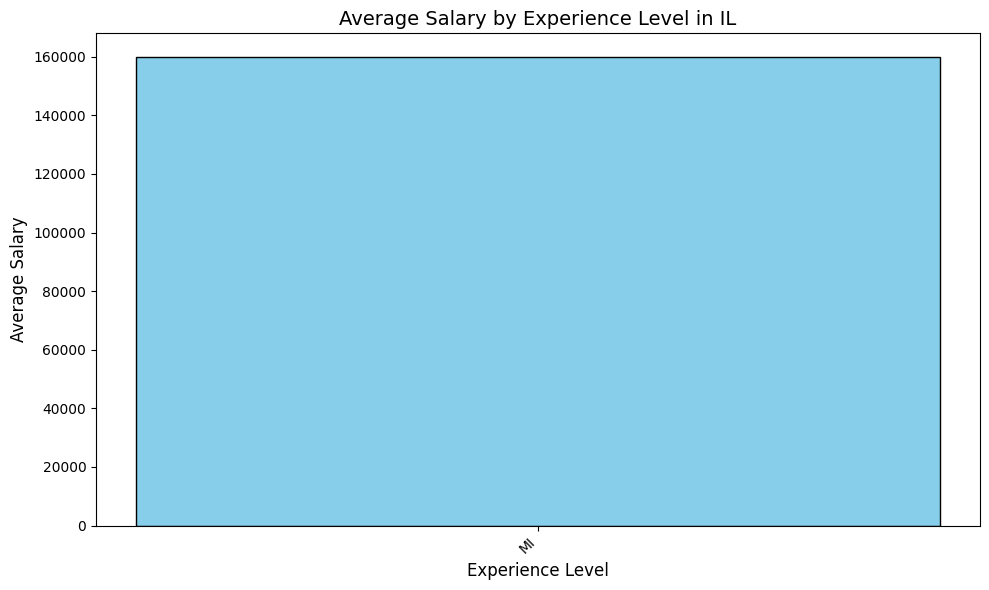

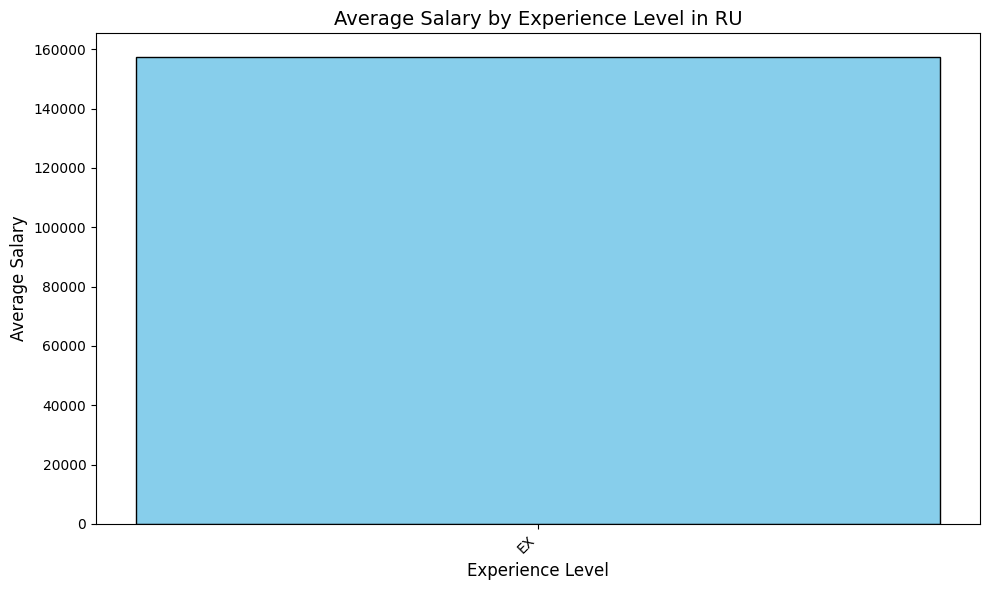

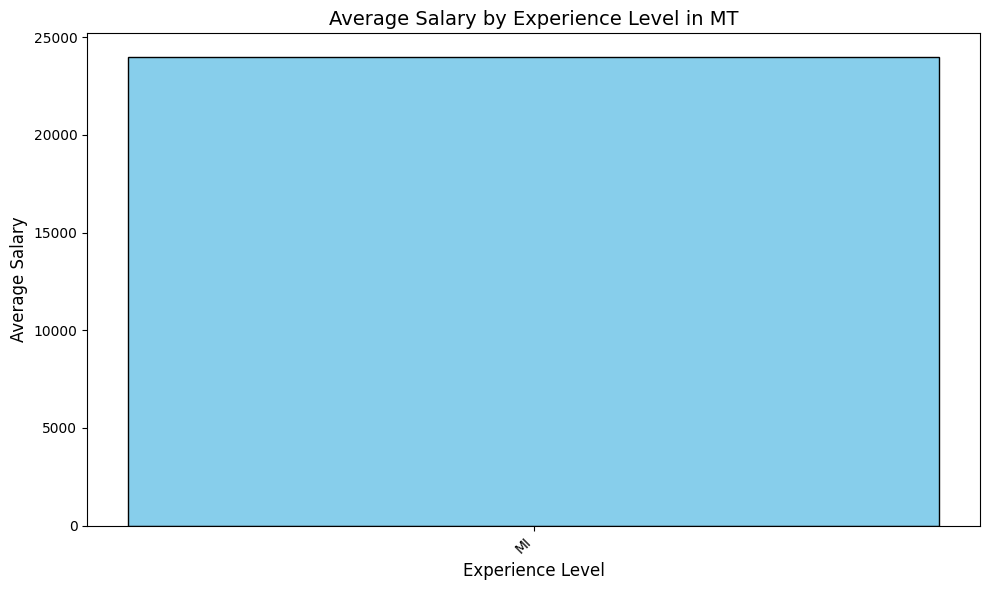

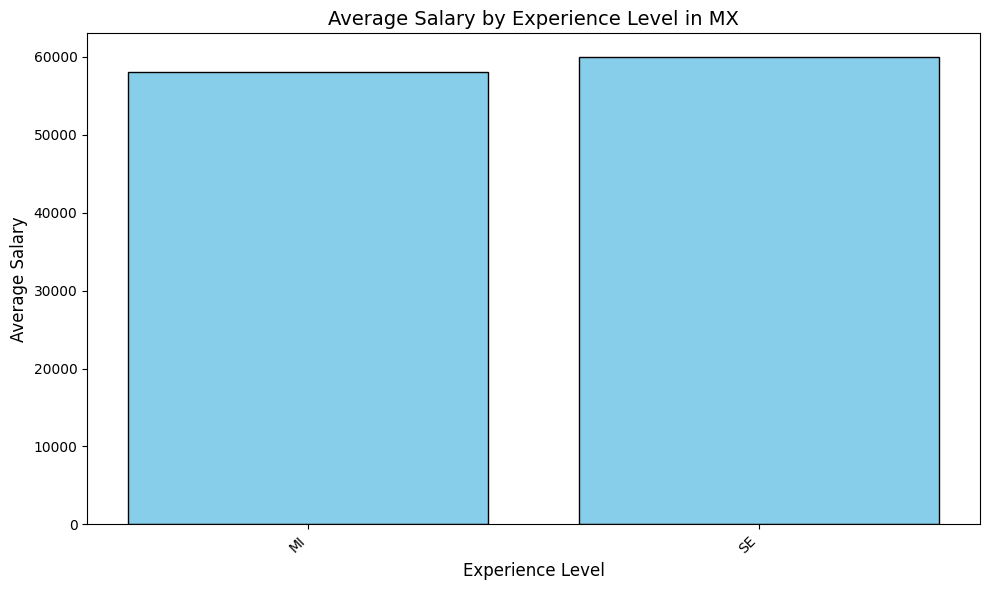

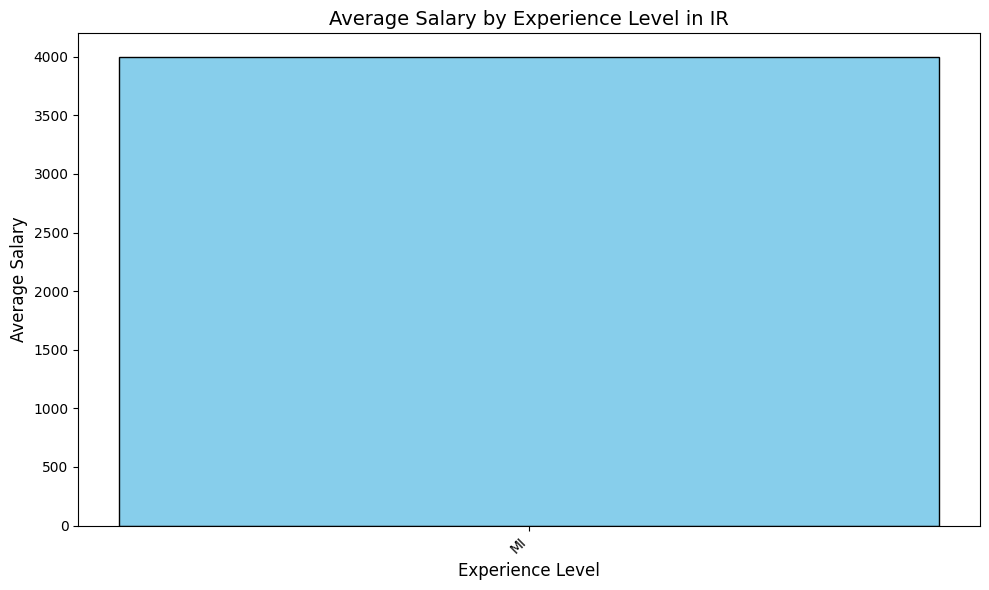

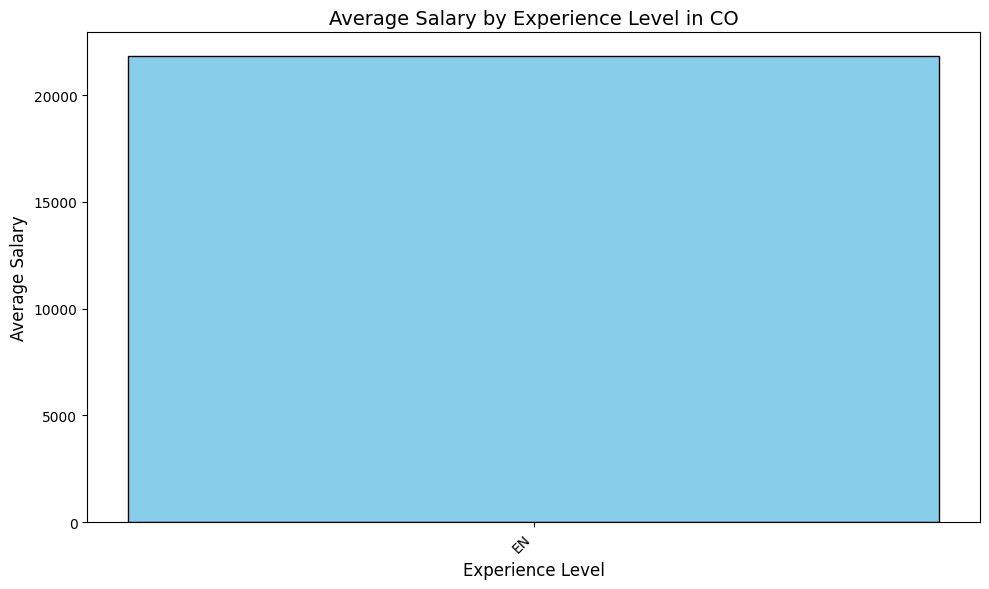

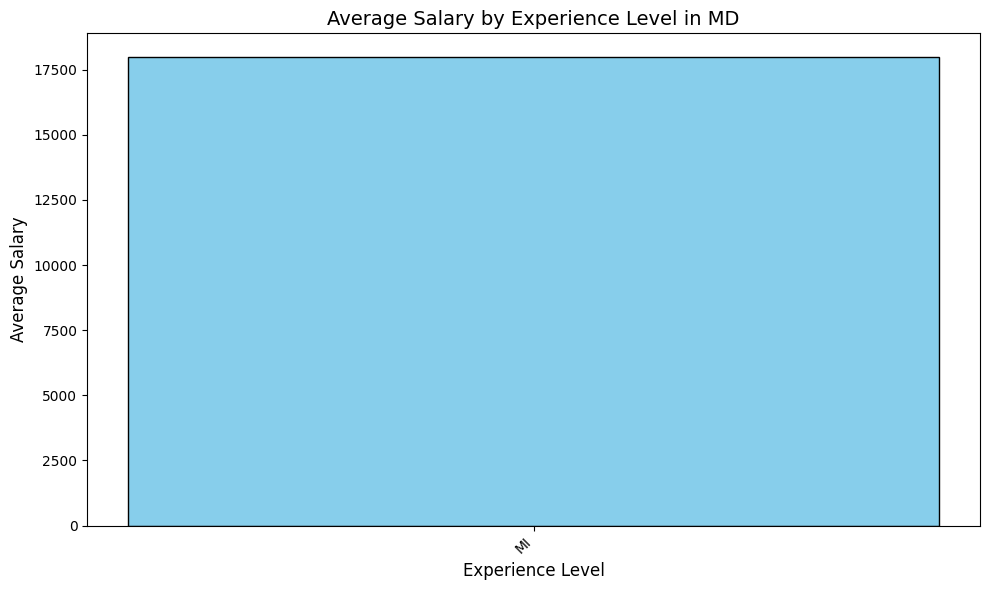

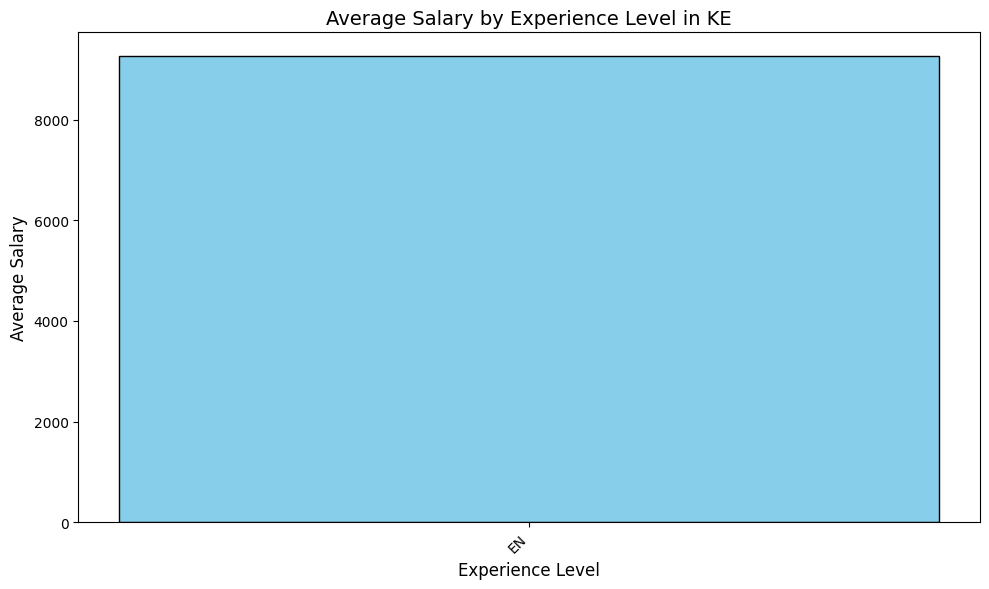

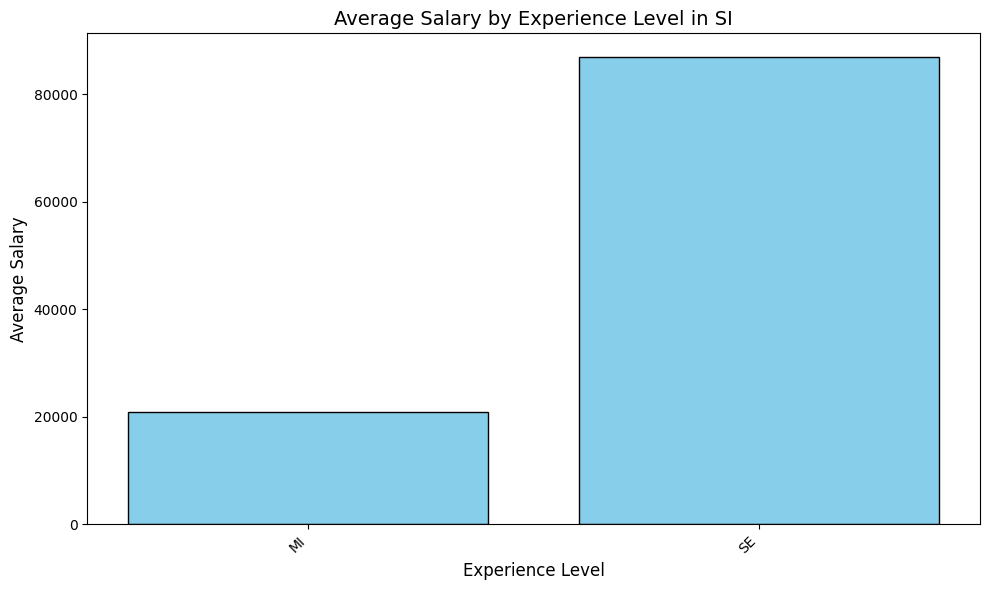

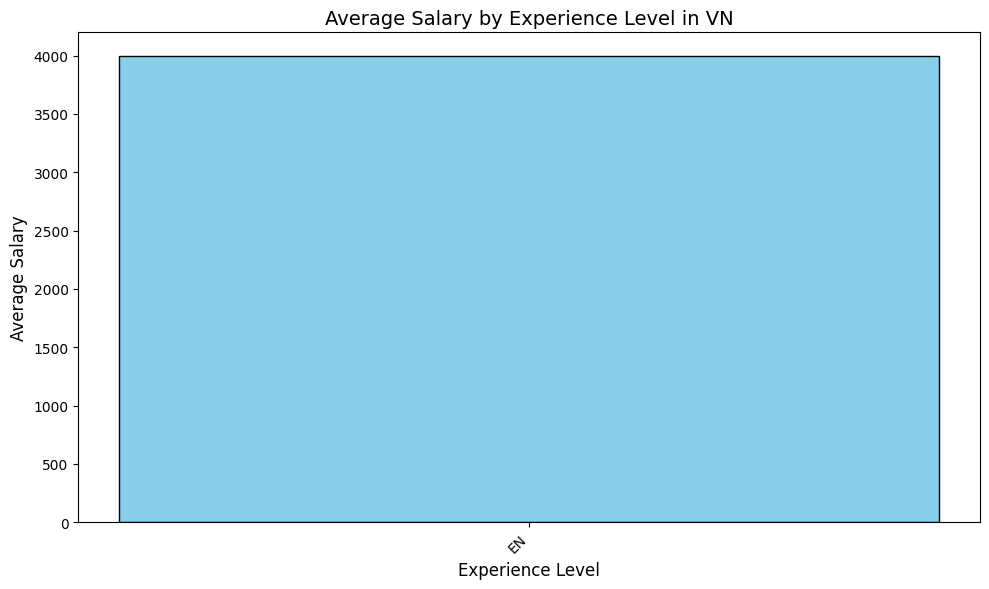

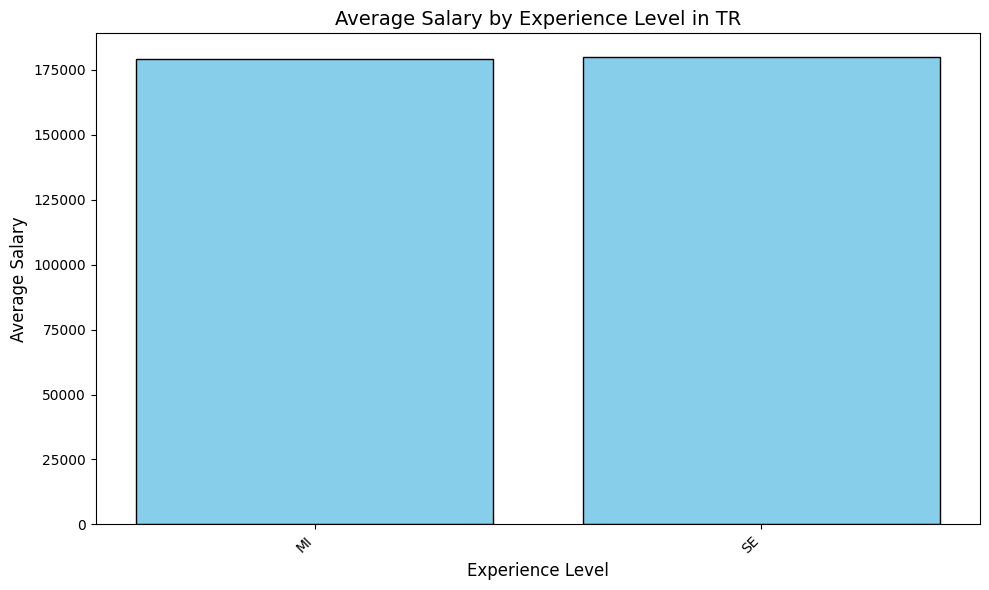

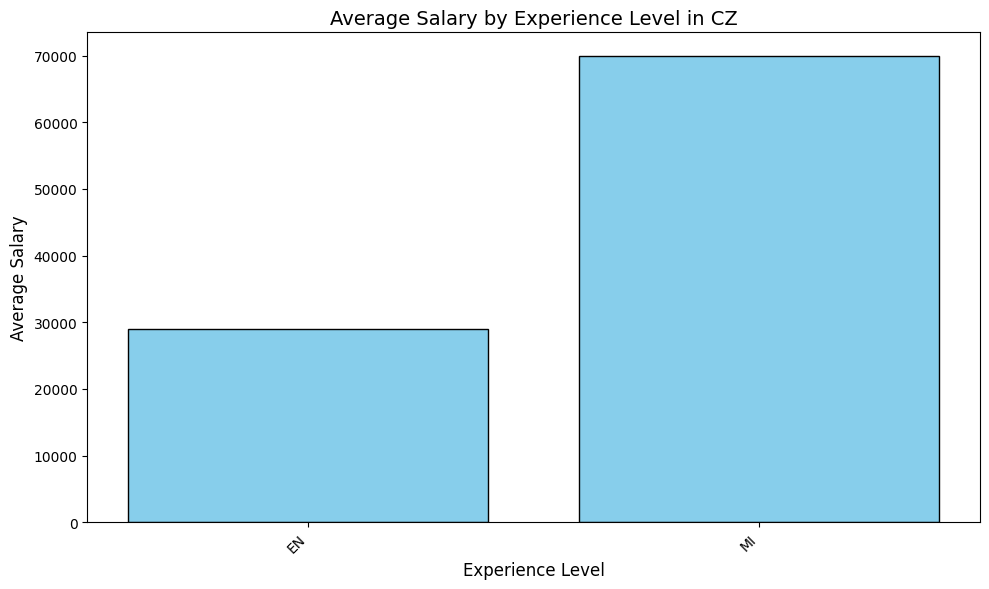

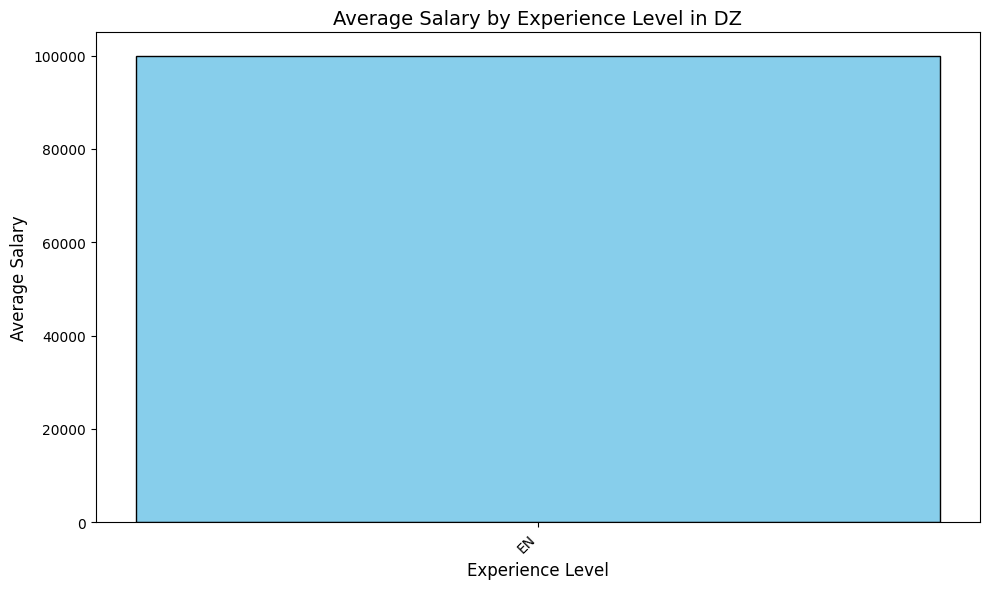

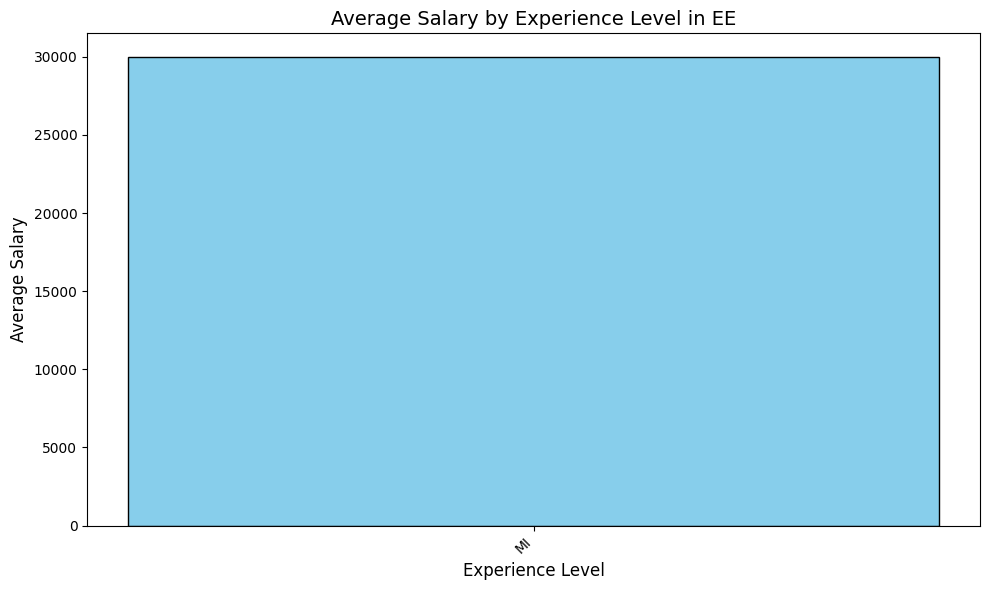

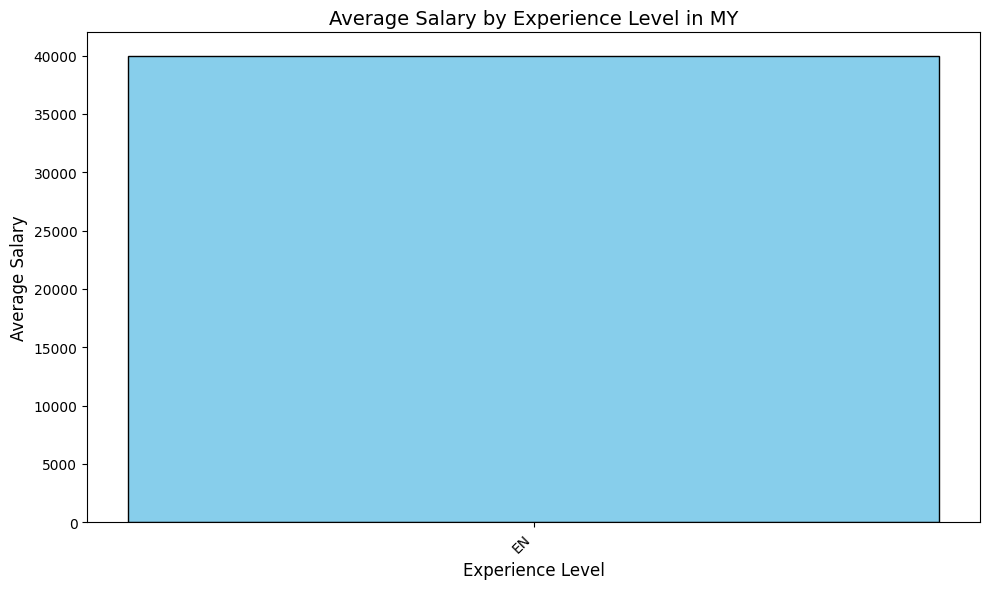

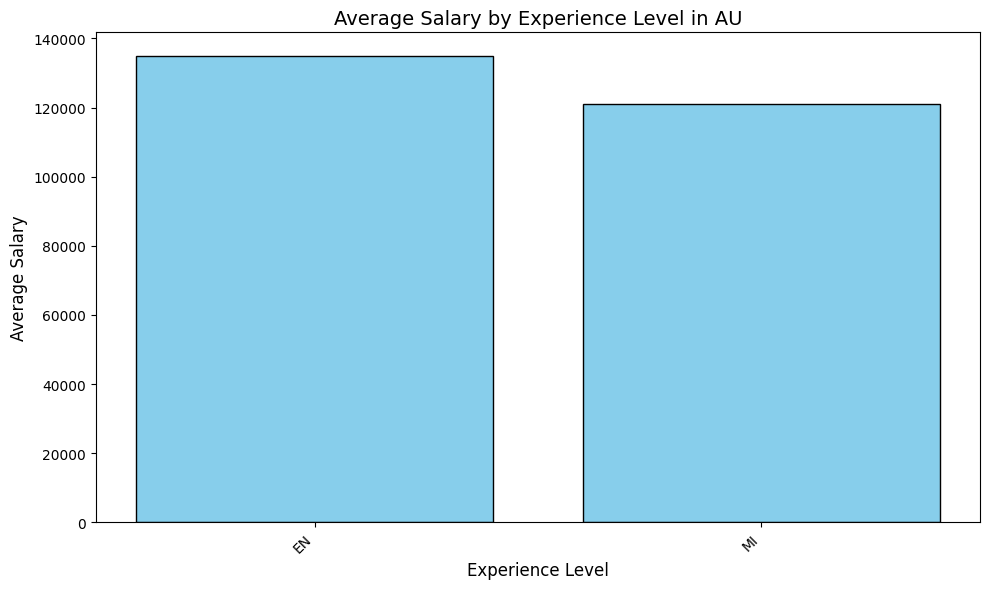

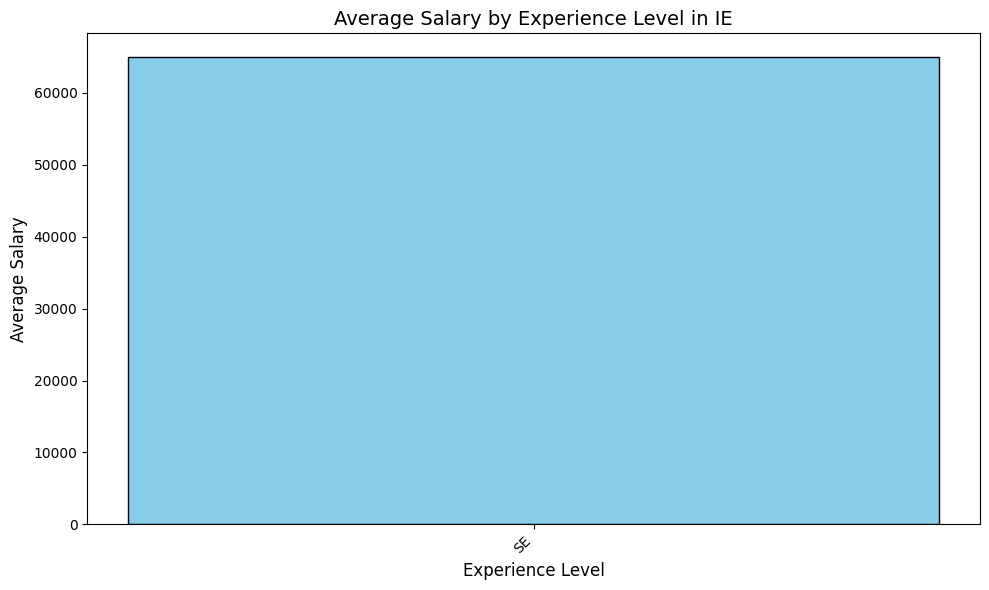

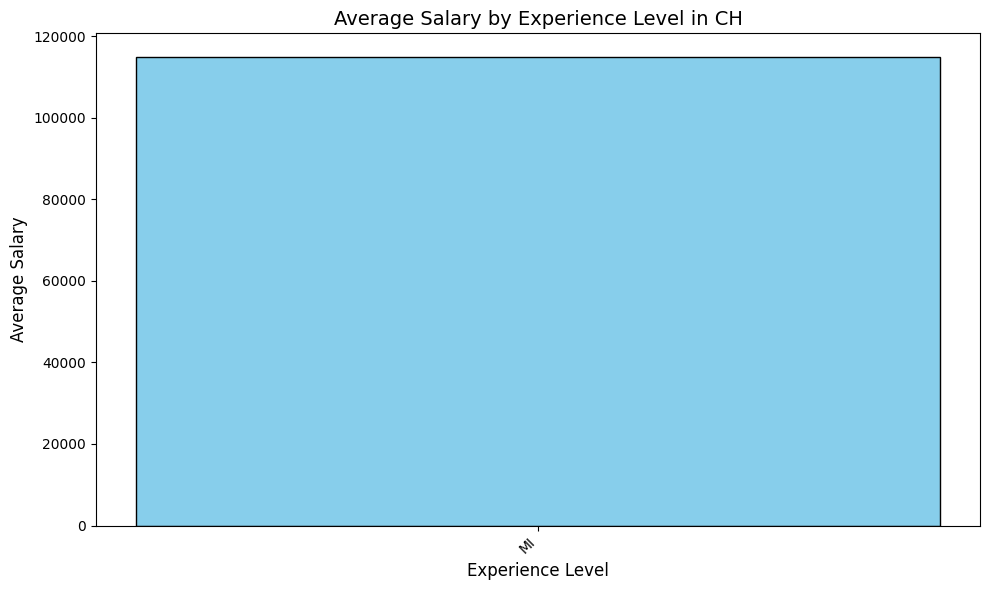

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
locations = ds_salaries_new['company_location'].unique()

for location in locations:
    location_data = location_experience_stats[location_experience_stats['company_location'] == location]



    plt.figure(figsize=(10, 6))
    plt.bar(location_data['experience_level'], location_data['mean'], color='skyblue', edgecolor='black')
    plt.title(f'Average Salary by Experience Level in {location}', fontsize=14)
    plt.xlabel('Experience Level', fontsize=12)
    plt.ylabel('Average Salary', fontsize=12)
    plt.xticks(rotation=45, ha='right')


    plt.tight_layout()
    plt.show()